<Axes: xlabel='Bucket Center', ylabel='Probability'>

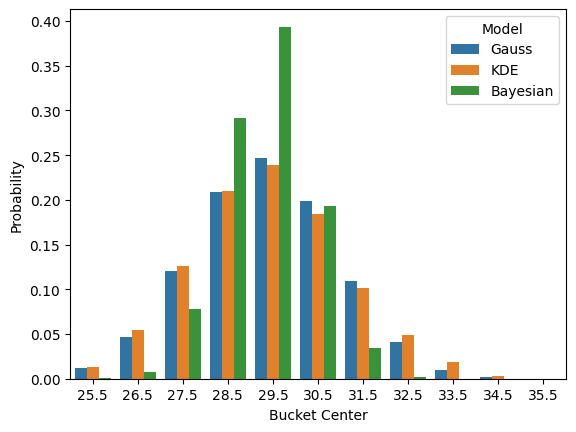

In [1]:
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
sys.path.append("/Users/gabriel/Desktop/Quant_Project/Quant-Summer-Project")
from scipy.stats import norm
from tests.fixtures.synthetic_data import synthetic_actual_df, synthetic_previous_df
from data import fetcher
from data.fetcher import (
fetch_data,
get_tommorows_wheather,
pair_dataframes,compute_forecast_error,
fetch_previous_forecast_data,
get_daily_max,
call_fetcher_functions,
)

from models.bayesian_model import (
bayesian_interference,
posterior_probability,
)

from models.baseline import (
gaussian_probability
)
from models.kde_model import (
kde_estimate
)
from data.cleaner import clean_data
from data.loader import (
add_event_column,
filter_summer
)
from config.settings import (
HISTORICAL_START,
HISTORICAL_END,
DEFAULT_CITY,
TOMMORROWS_DATE,
FORECAST_START,
FORECAST_END,
LOWER_BOUND,
UPPER_BOUND,

)

#fetcher.fetch_data = lambda *args, **kwargs: synthetic_actual_df()
#fetcher.fetch_previous_forecast_data = lambda *args, **kwargs: synthetic_previous_df()
#fetcher.get_tommorows_wheather = lambda *args, **kwargs: 30
df_pair = call_fetcher_functions(FORECAST_START,FORECAST_END)

df_raw = fetch_data(HISTORICAL_START,HISTORICAL_END)


df_clean = clean_data(df_raw)


df_event = add_event_column(df_clean)


df_temp_summer = filter_summer(df_event)

df_temp_list = df_temp_summer["temperature_2m_max"].to_list()
day = df_pair["date"].to_list()[-1]
data = []
sigma_posterior, _, _, my_posterior, _, _ = bayesian_interference(df_temp_list,day,df_pair)
for i in range(25,36):
    bucket_center = i +0.5
    P_baseline,_,_ = gaussian_probability(df_temp_list,i,i+1)
    P_KDE = kde_estimate(df_temp_list,i,i+1)
    #To not run out of API calls
    P_Bayesian_Inference = norm.cdf((i+1 - my_posterior)/sigma_posterior) - norm.cdf((i - my_posterior)/sigma_posterior)
    data.append( (bucket_center, "Gauss", P_baseline))
    data.append( (bucket_center, "KDE", P_KDE))
    data.append( (bucket_center, "Bayesian",P_Bayesian_Inference ))

long_df = pl.DataFrame(data,schema = ['Bucket Center', 'Model', 'Probability'],orient = "row" )


sns.barplot(data=long_df, x="Bucket Center", y="Probability", hue="Model")




This chart shows where the three models disagree, but it doesn't tell us which one is right — there's no ground truth on it, just three sets of assumptions compared to each other.
For Gauss vs KDE specifically, we already found the answer in notebook 03: comparing both against the actual empirical histogram of real summer days showed KDE tracks reality better at the "shoulder" buckets, while Gaussian does better right at the center and out in the extreme tail — a result of the underlying data being a mixture of three differently-shaped months (June/July/August) that a single symmetric Gaussian can't fully capture.
For Bayesian, this kind of check doesn't even apply the same way — it isn't predicting "the general shape of summer," it's making a claim about one specific day. The only real way to judge whether it's any good is to check it across many days: of all the times it said "70% chance," did the event actually happen about 70% of the time? That's a calibration question, not a distribution-shape question, and it's what the evaluation notebook (Brier score, log loss, calibration curves) is for.
Here we can see what two separate questions the models answer. KDE and Gauss is general climatological and Bayesian is  one particular day's . So Gauss and KDE represent what typical for any summer day in general. The bayesian bars represent specific days forecast updated estimate , whatever days forecast happend to be plugged in.
One thing to be aware of if you ran this tommorow then Gauss and KDE would look the same thus they only depend on historical data where as Bayesian would not, thus it depens on tommorows forecast.


In [7]:
from evaluation.eval_loop import (
run_eval,
)
from evaluation.scoring import (
brier_score,
log_loss,
skill_score
)
from pricing.fair_value import ( 
create_buckets,
build_probability_vector,
find_correct_bucket,

)
from models import baseline
from models.bayesian_model import posterior_probability
from models.kde_model import kde_estimate
from data import fetcher, cleaner, loader
from config import settings

#fetcher.fetch_data = lambda *args, **kwargs: synthetic_actual_df()
#fetcher.fetch_previous_forecast_data = lambda *args, **kwargs: synthetic_previous_df()
#fetcher.get_tommorows_wheather = lambda *args, **kwargs: 30


df_raw = fetcher.fetch_data(settings.HISTORICAL_START, settings.HISTORICAL_END)
df_clean = cleaner.clean_data(df_raw)
df_event = loader.add_event_column(df_clean)
df_temp_summer = loader.filter_summer(df_event)
df_summer = df_temp_summer["temperature_2m_max"].to_list()

df_pair = fetcher.call_fetcher_functions(settings.FORECAST_START, settings.FORECAST_END)

buckets = create_buckets(25, 36)


gaussian_prob_fn = lambda low, high: baseline.gaussian_probability(df_summer, low, high)[0]
kde_prob_fn = lambda low, high: kde_estimate(df_summer, low, high)

bayesian_factory = lambda day: (lambda low, high: posterior_probability(df_summer, day, df_pair, low, high))

sample_vector = build_probability_vector(gaussian_prob_fn, buckets)
sample_index = find_correct_bucket(df_pair["actual_temp"].to_list()[0], buckets)


prob_matrix_gauss, correct_indices_gauss = run_eval(lambda day: gaussian_prob_fn, buckets, df_pair)
prob_matrix_kde, correct_indices_kde = run_eval(lambda day: kde_prob_fn, buckets, df_pair)
prob_matrix_bayes, correct_indices_bayes = run_eval(bayesian_factory, buckets, df_pair)

#print(f"prob_matrix_gauss is {prob_matrix_gauss} has  {correct_indices} ,prob_matrix_kde is {prob_matrix_kde} and prob_matrix_bayes {prob_matrix_bayes}")

brier_gauss = brier_score(prob_matrix_gauss, correct_indices_gauss)
brier_kde = brier_score(prob_matrix_kde, correct_indices_kde)
brier_bayes = brier_score(prob_matrix_bayes, correct_indices_bayes)

log_loss_gauss = log_loss(prob_matrix_gauss, correct_indices_gauss)
log_loss_kde = log_loss(prob_matrix_kde, correct_indices_kde)
log_loss_bayes = log_loss(prob_matrix_bayes, correct_indices_bayes)


print(f"brier_gauss {brier_gauss}")
print(f"brier_kde {brier_kde}")
print(f"brier_bayes {brier_bayes}")

print(f"log_loss_gauss {log_loss_gauss}")
print(f"log_loss_kde {log_loss_kde}")
print(f"log_loss_bayes {log_loss_bayes}")

kde_v_gauss_brier  = skill_score(brier_kde, brier_gauss)
bayes_v_gauss_brier = skill_score(brier_bayes, brier_gauss)
bayes_v_kde_brier = skill_score(brier_bayes, brier_kde)

kde_v_gauss_log  = skill_score(log_loss_kde, log_loss_gauss)
bayes_v_gauss_log = skill_score(log_loss_bayes,log_loss_gauss)
bayes_v_kde_log = skill_score(log_loss_bayes, log_loss_kde)


print(f"kde_v_gauss_brier {kde_v_gauss_brier}")
print(f"bayes_v_gauss_brier {bayes_v_gauss_brier }")
print(f"bayes_v_kde_brier {bayes_v_kde_brier}")


print(f"kde_v_gauss_log {kde_v_gauss_log}")
print(f"bayes_v_gauss_log {bayes_v_gauss_log}")
print(f"bayes_v_kde_log {bayes_v_kde_log}")

lens = len(correct_indices_gauss)
print(f"days we ran on {lens}")


brier_gauss 0.8885718788750293
brier_kde 0.8845861573365565
brier_bayes 0.744227141851493
log_loss_gauss 2.286335572917477
log_loss_kde 2.263537268477451
log_loss_bayes 1.52917784143537
kde_v_gauss_brier 0.004485536435745452
bayes_v_gauss_brier 0.1624457632018279
bayes_v_kde_brier 0.15867195560427638
kde_v_gauss_log 0.009971547794681013
bayes_v_gauss_log 0.3311664921155629
bayes_v_kde_log 0.32443001370860636
days we ran on 1135



The experiment ran on 1135 days.
What the scoring shows is that forecast-conditiong beats pure climatology. The raw Brier and log-loss score per model using Hong Kong data 
Brier:
brier_gauss 0.8885718788750293
brier_kde 0.8845861573365565
brier_bayes 0.744227141851493
Log loss:
log_loss_gauss 2.286335572917477
log_loss_kde 2.263537268477451
log_loss_bayes 1.52917784143537

This is what we get when we compare that to a baseline(gauss) :
kde_v_gauss_brier 0.004485536435745452
bayes_v_gauss_brier 0.1624457632018279
bayes_v_kde_brier 0.15867195560427638 (baseline kde)
kde_v_gauss_log 0.009971547794681013
bayes_v_gauss_log 0.3311664921155629
bayes_v_kde_log 0.32443001370860636 (baseline kde)

This tells us the bayesian beats both gauss and kde, and where kde just barely beats gauss.  Bayseian win properly beacuse trends are more important the historic data and that symmetric data. 

Something intressting is that a  uniform 11-bucket guess (zero skill) would score ~0.909 Brier / ~2.398 log-loss — and my Gaussian/KDE numbers (0.885-0.889, 2.26-2.29) sit only modestly better than that.




